# Master BigData UCM 2023

## 1. Datos vehículos a la venta 2016 en UK

Propósito:

- Facilitar la lectura del .csv que contiene los datos de este ejemplo



In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import plotnine
from plotnine import *

### Carga de datos

Este dataset tiene ya 7 años pero sigue siendo válido para nuestro propósito. 

La principal ventaja es que tiene una variale de grupo (o "factor") creada en español (la variable "Tipo") para facilitar los gráficos por tipo de vehículo.

In [3]:
df= pd.read_pickle("datos_vehiculos_ES_2024.pkl")

In [4]:
df.shape

(5237, 16)

In [5]:
df.describe(include = 'all')

,Mk,Cn,Ct,Ft,m (kg),ep (KW),ec (cm3),z (Wh/km),Ewltp (g/km),W (mm),At1 (mm),At2 (mm),Fuel consumption,Electric range (km),total_registros,last_date
count,5237,5236,5237,5237,5236.000000,5228.000000,4514.000000,1310.000000,5235.000000,0,0,0,3615.000000,1309.000000,5237.00000,5237
unique,75,1899,1,8,NaN,NaN,NaN,NaN,NaN,0,0,0,NaN,NaN,NaN,252
top,FORD,TOURNEO CUSTOM,M1,petrol,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-12-30
freq,963,256,5237,2154,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1271
mean,NaN,NaN,NaN,NaN,1807.823147,131.286534,1885.421134,185.452672,126.397708,NaN,NaN,NaN,5.944371,264.252101,201.62975,NaN
std,NaN,NaN,NaN,NaN,406.607704,82.745225,701.916127,36.553806,76.956617,NaN,NaN,NaN,2.506970,199.549111,683.61197,NaN
min,NaN,NaN,NaN,NaN,865.000000,8.000000,875.000000,101.000000,0.000000,NaN,NaN,NaN,0.300000,12.000000,1.00000,NaN
25%,NaN,NaN,NaN,NaN,1489.000000,88.000000,1497.000000,158.000000,87.500000,NaN,NaN,NaN,5.100000,63.000000,2.00000,NaN
50%,NaN,NaN,NaN,NaN,1744.000000,110.000000,1968.000000,177.000000,134.000000,NaN,NaN,NaN,5.800000,274.000000,13.00000,NaN
75%,NaN,NaN,NaN,NaN,2130.000000,140.000000,1997.000000,201.750000,179.000000,NaN,NaN,NaN,7.300000,434.000000,92.00000,NaN


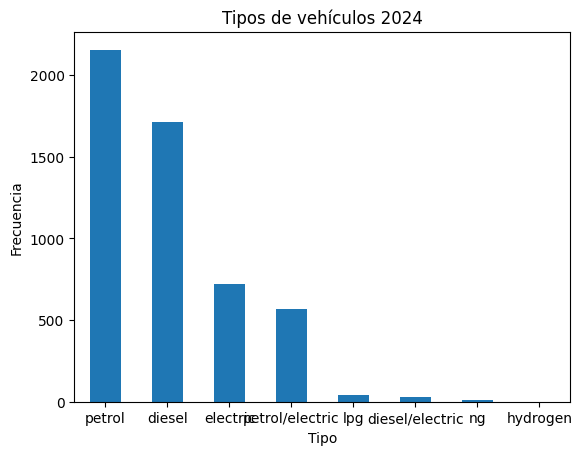

In [6]:
count_classes = df['Ft'].value_counts(sort = True)
count_classes.plot(kind = 'bar', rot=0)
plt.title("Tipos de vehículos 2024")
plt.xlabel("Tipo")
plt.ylabel("Frecuencia");

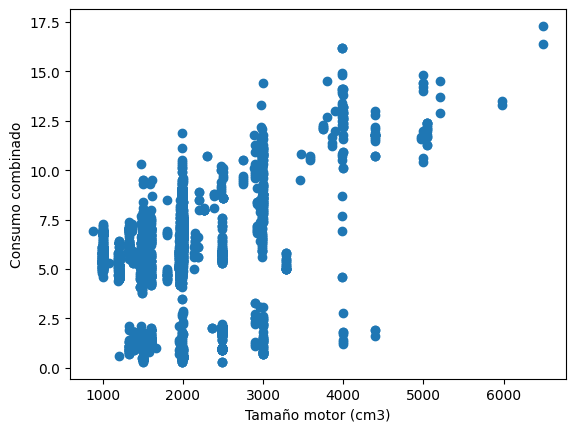

In [7]:
plt.scatter(df['ec (cm3)'], 
            df['Fuel consumption '])

plt.xlabel('Tamaño motor (cm3)')
plt.ylabel('Consumo combinado')
plt.show()

# 2. Visualizaciones con ggplot

Además del contenido recogido en la docu. teórica, es aconsejable seguir este excelente (y práctico) tutorial:

https://realpython.com/ggplot-python/


## 2.1 Scatterplot dataset vehículos



In [8]:
(
ggplot(df) +
    aes(x = 'EngineCapacity', 
        y = 'MetricCombined')
)

PlotnineError: "Could not evaluate the 'x' mapping: 'EngineCapacity' (original error: name 'EngineCapacity' is not defined)"

/home/pedro/Escritorio/UCM_2026/entorno_junio/lib/python3.12/site-packages/plotnine/layer.py:374: PlotnineWarning: geom_point : Removed 1622 rows containing missing values.


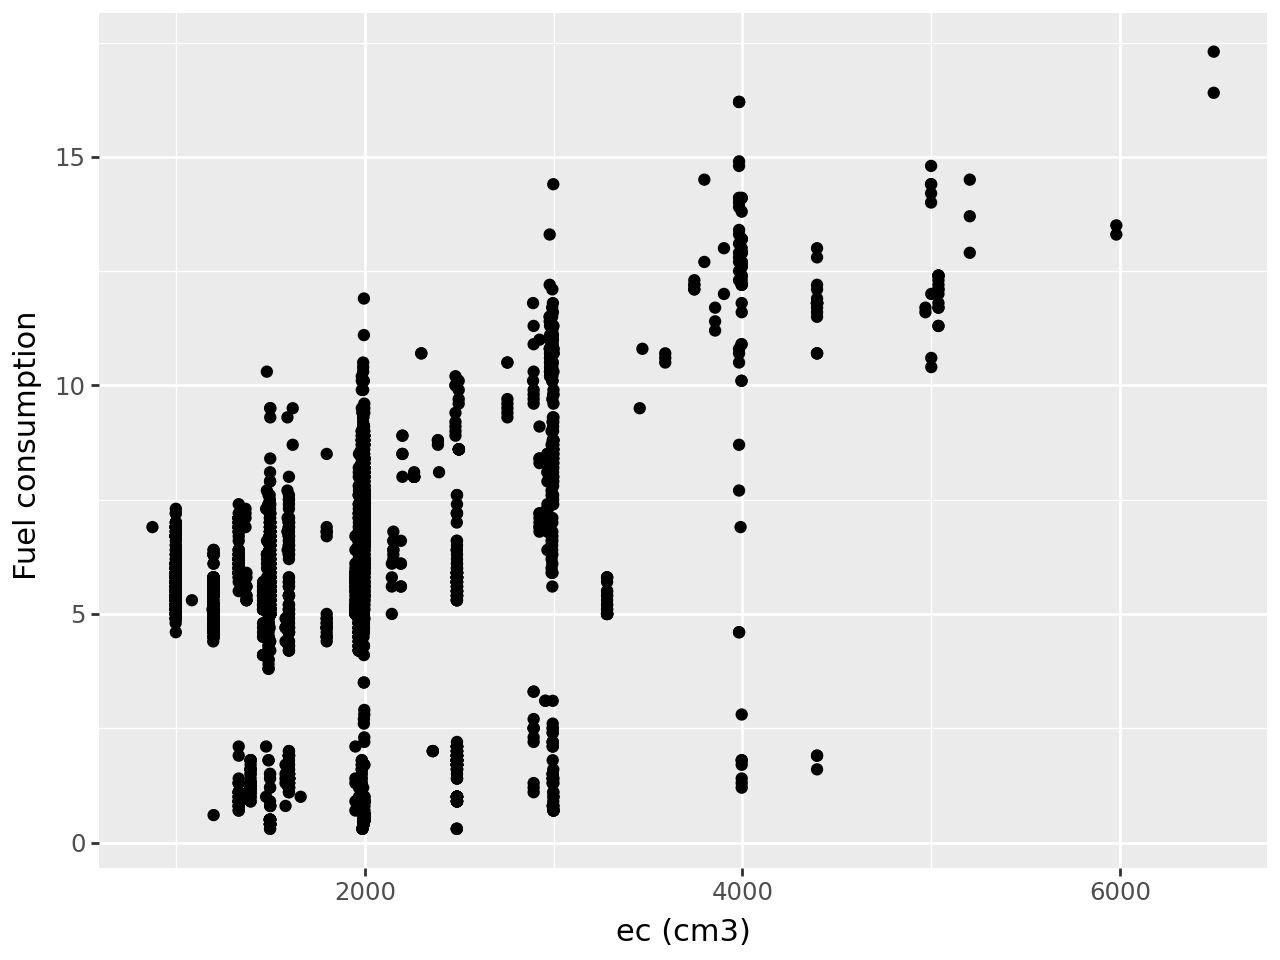

In [9]:
(
    ggplot(df)  # What data to use
    + aes(x = 'ec (cm3)', 
          y = 'Fuel consumption ')  # What variable to use
    + geom_point()   # Geometric object to use for drawing
)

## Relación peso y tamaño de motor, con escala de color para emisiones CO2 (wltp)

/home/pedro/Escritorio/UCM_2026/entorno_junio/lib/python3.12/site-packages/plotnine/layer.py:374: PlotnineWarning: geom_point : Removed 724 rows containing missing values.


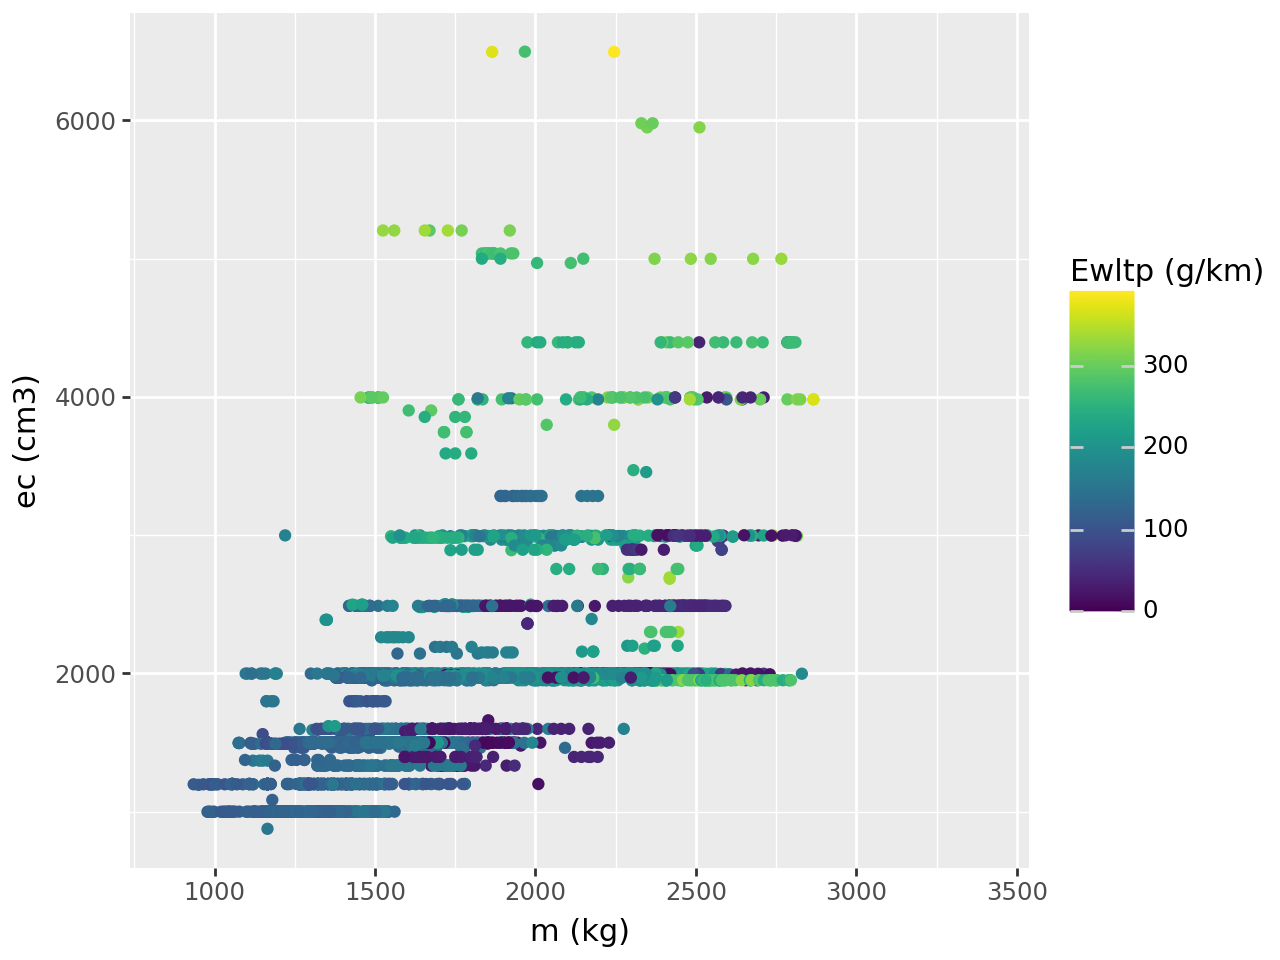

In [10]:
(
    ggplot(df)  # What data to use
    + aes(x = 'm (kg)', 
          y = 'ec (cm3)',
         color = 'Ewltp (g/km)')  # What variable to use
    +  geom_point()   # Geometric object to use for drawing
)

In [11]:
import sklearn
import skmisc

/home/pedro/Escritorio/UCM_2026/entorno_junio/lib/python3.12/site-packages/plotnine/stats/smoothers.py:342: PlotnineWarning: Confidence intervals are not yet implemented for lowess smoothings.
/home/pedro/Escritorio/UCM_2026/entorno_junio/lib/python3.12/site-packages/plotnine/layer.py:374: PlotnineWarning: geom_point : Removed 1622 rows containing missing values.


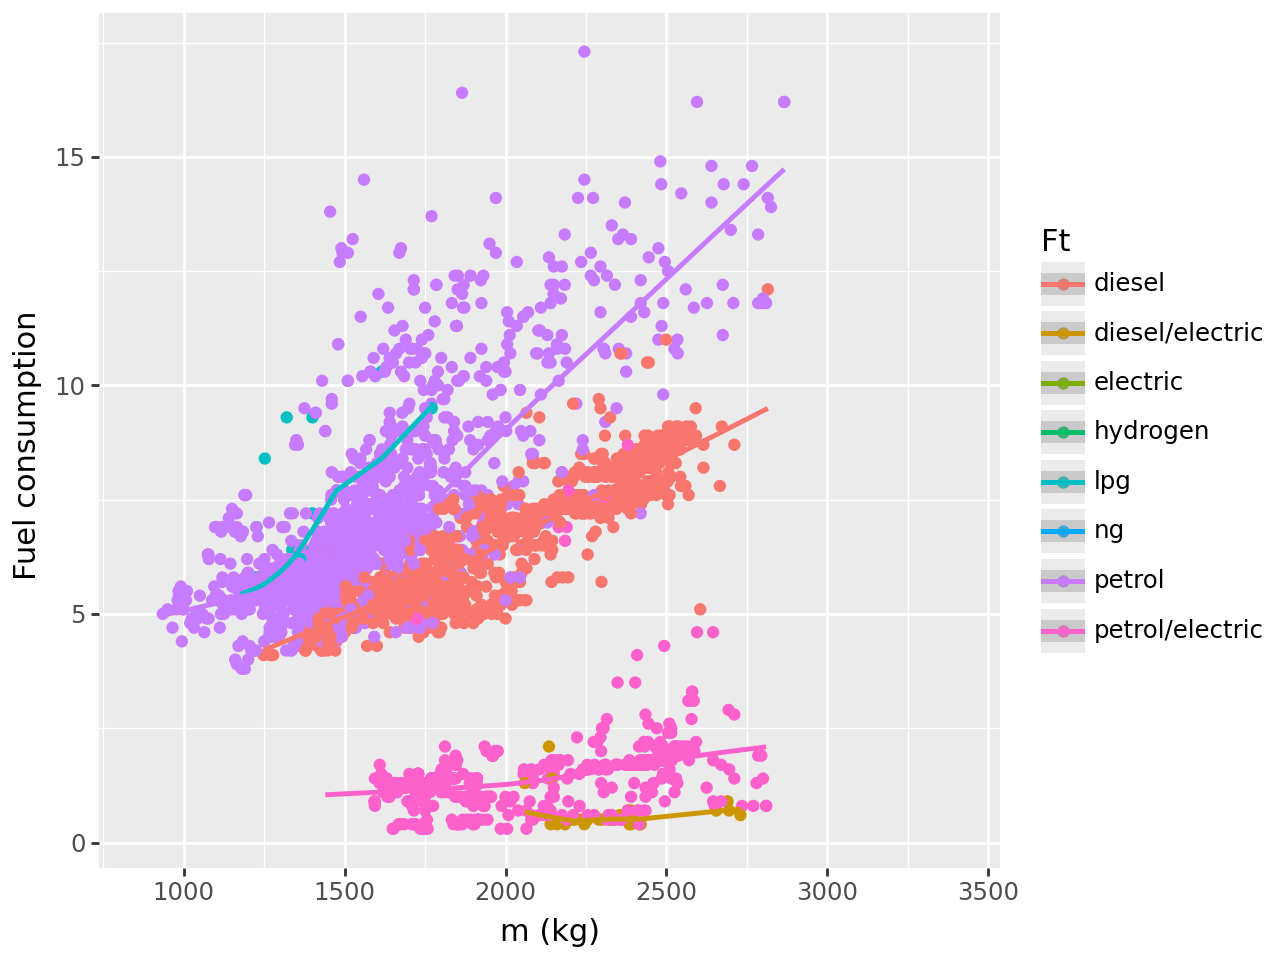

In [12]:
(
    ggplot(df)  # What data to use
    + aes(x = 'm (kg)', 
          y = 'Fuel consumption ',
         color = 'Ft')  # What variable to use
    + geom_point()
    + geom_smooth(method = 'lowess') 
#    + geom_smooth(method = 'lm')# Geometric object to use for drawing
)

## Relación peso y consumo por tipo de motor

/home/pedro/Escritorio/UCM_2026/entorno_junio/lib/python3.12/site-packages/plotnine/stats/smoothers.py:342: PlotnineWarning: Confidence intervals are not yet implemented for lowess smoothings.
/home/pedro/Escritorio/UCM_2026/entorno_junio/lib/python3.12/site-packages/plotnine/layer.py:374: PlotnineWarning: geom_point : Removed 1622 rows containing missing values.


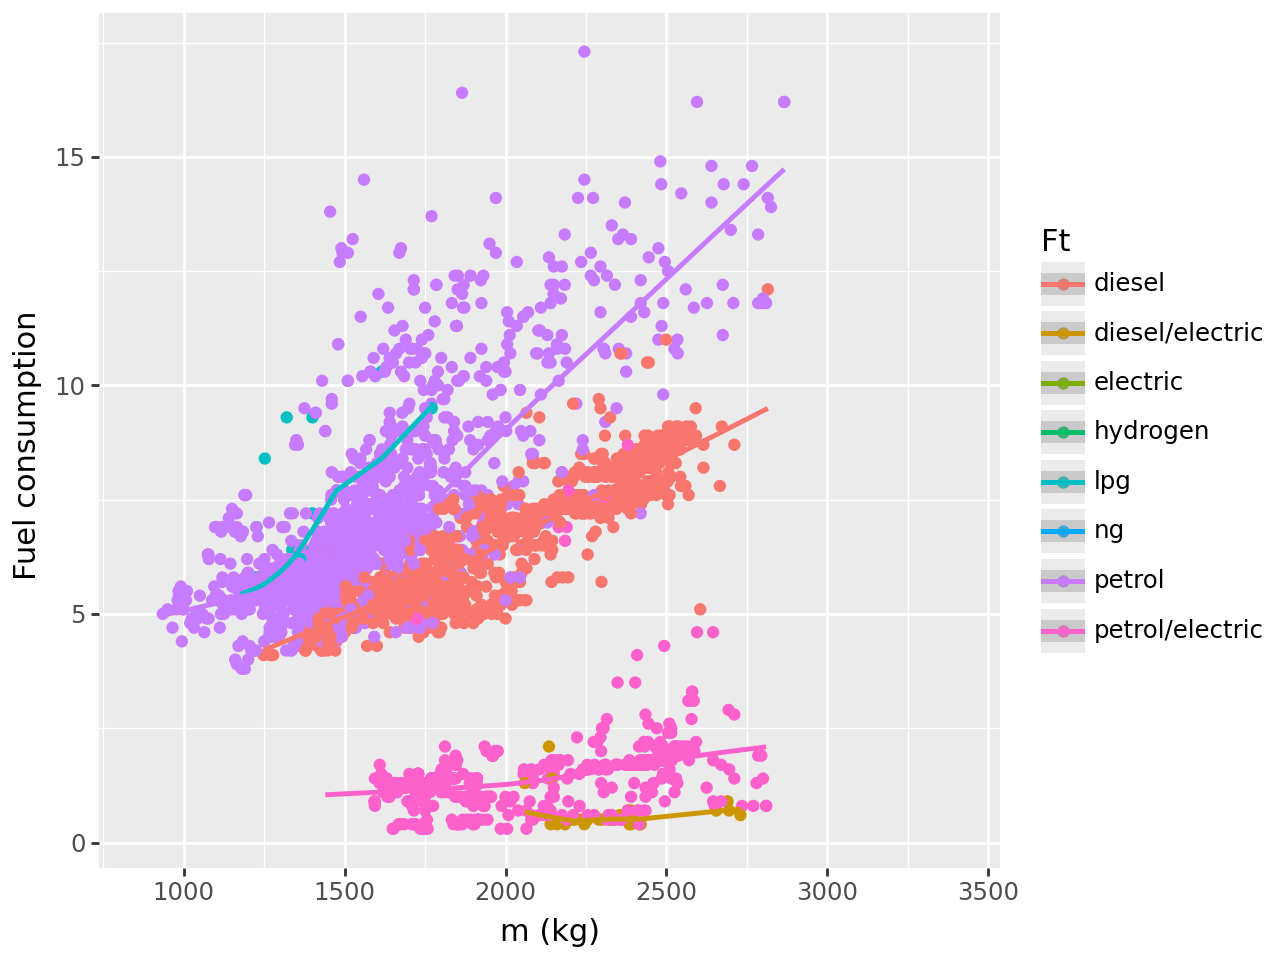

In [13]:
(
    ggplot(df)  # What data to use
    + aes(x = 'm (kg)', 
          y = 'Fuel consumption ',
         color = 'Ft')  # What variable to use
    + geom_point()
    + geom_smooth(method = 'lowess') 
#    + geom_smooth(method = 'lm')# Geometric object to use for drawing
)

## (como en 2016) Relación tamaño de motor y consumo por tipo de motor

/home/pedro/Escritorio/UCM_2026/entorno_junio/lib/python3.12/site-packages/plotnine/stats/smoothers.py:342: PlotnineWarning: Confidence intervals are not yet implemented for lowess smoothings.
/home/pedro/Escritorio/UCM_2026/entorno_junio/lib/python3.12/site-packages/statsmodels/nonparametric/smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
/home/pedro/Escritorio/UCM_2026/entorno_junio/lib/python3.12/site-packages/plotnine/layer.py:374: PlotnineWarning: geom_point : Removed 1622 rows containing missing values.


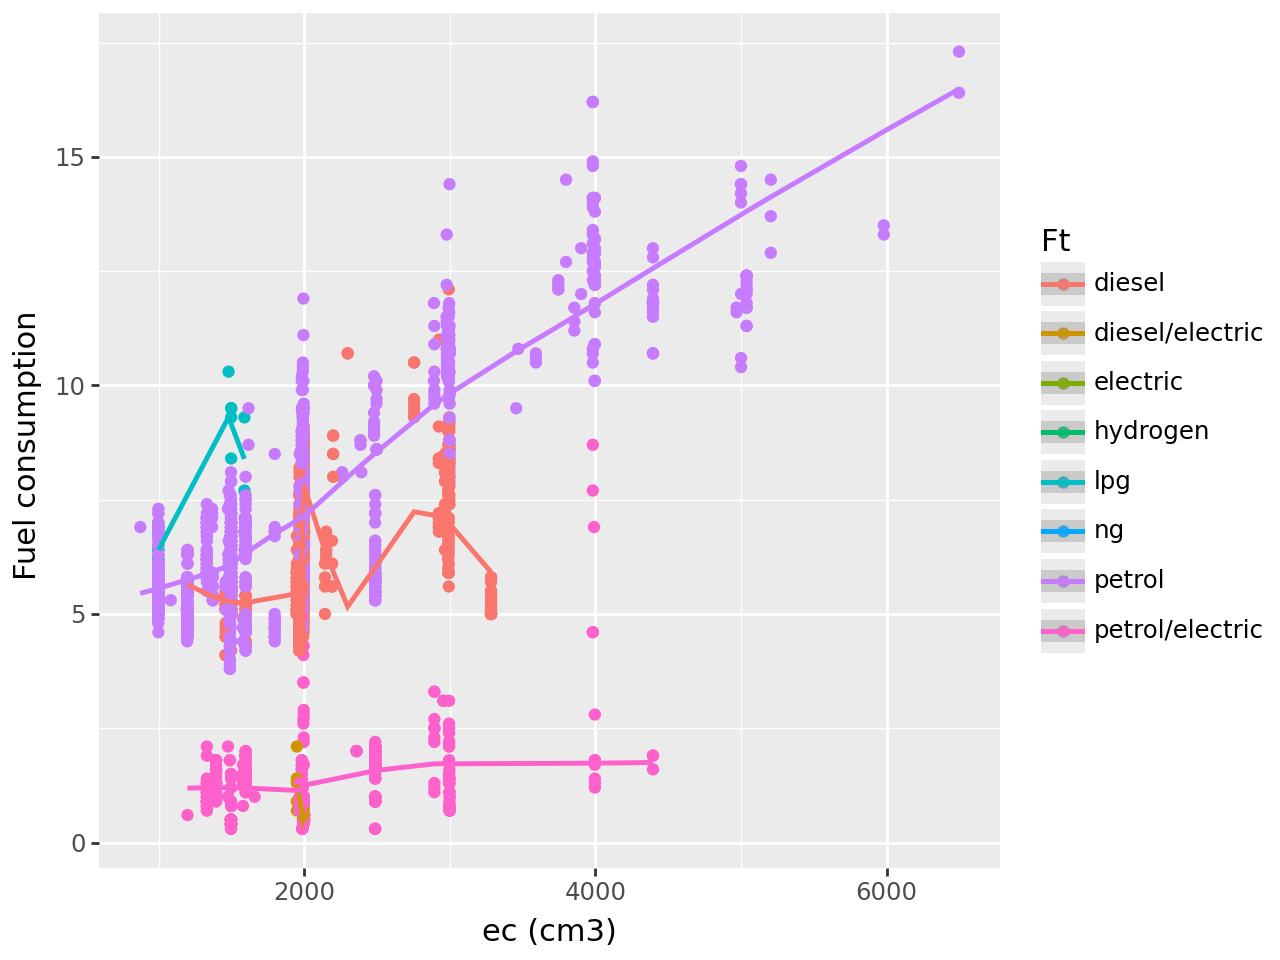

In [14]:
(
    ggplot(df)  # What data to use
    + aes(x = 'ec (cm3)', 
          y = 'Fuel consumption ',
         color = 'Ft')  # What variable to use
    + geom_point()
    + geom_smooth(method = 'lowess') 
#    + geom_smooth(method = 'lm')# Geometric object to use for drawing
)

/home/pedro/Escritorio/UCM_2026/entorno_junio/lib/python3.12/site-packages/plotnine/stats/smoothers.py:342: PlotnineWarning: Confidence intervals are not yet implemented for lowess smoothings.
/home/pedro/Escritorio/UCM_2026/entorno_junio/lib/python3.12/site-packages/statsmodels/nonparametric/smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
/home/pedro/Escritorio/UCM_2026/entorno_junio/lib/python3.12/site-packages/plotnine/layer.py:374: PlotnineWarning: geom_point : Removed 1622 rows containing missing values.


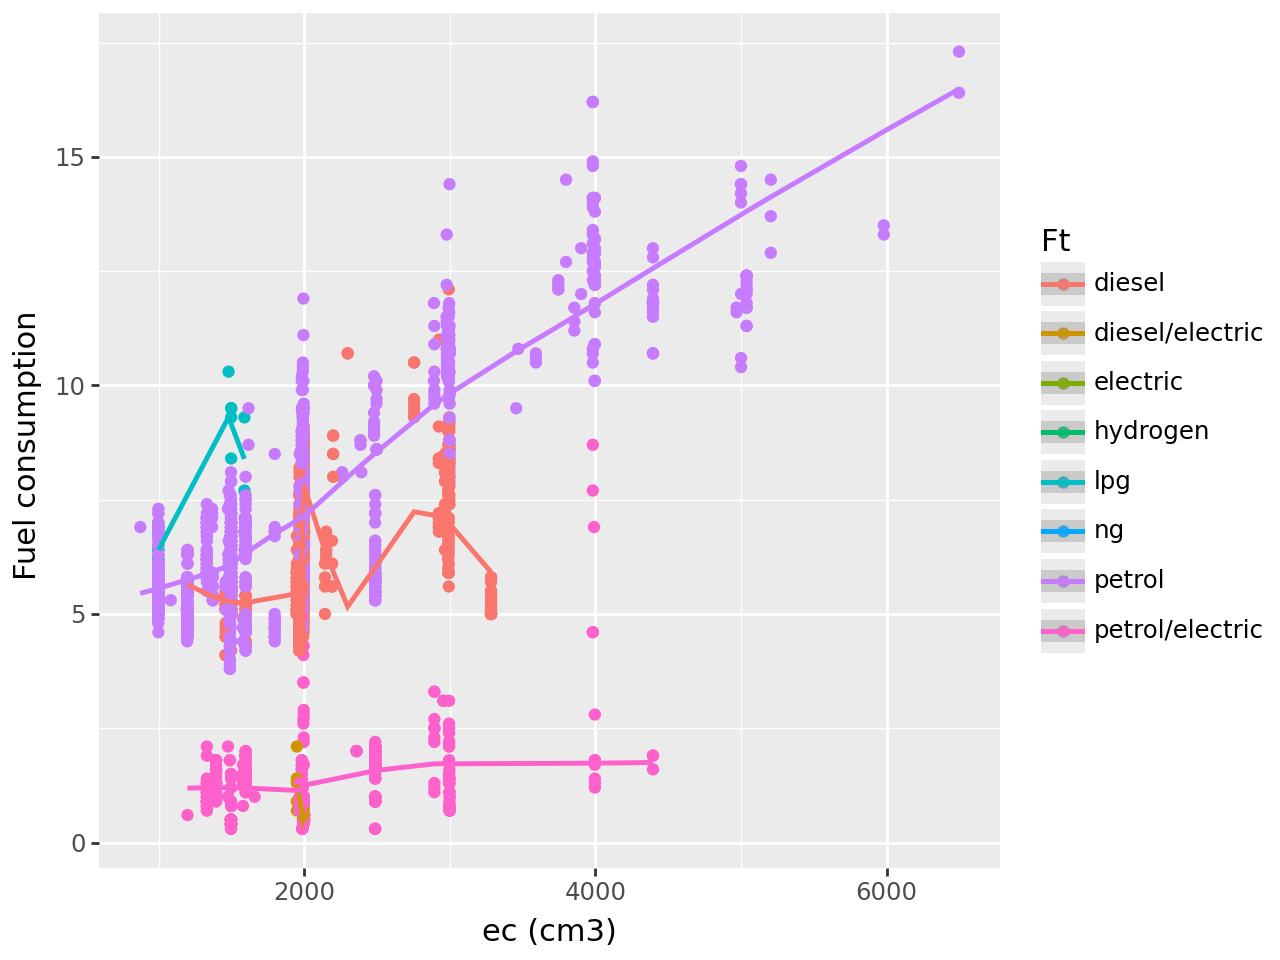

In [15]:
(
    ggplot(df)  # What data to use
    + aes(x = 'ec (cm3)', 
          y = 'Fuel consumption ',
         color = 'Ft')  # What variable to use
    + geom_point()
    + geom_smooth(method = 'lowess') 
#    + geom_smooth(method = 'lm')# Geometric object to use for drawing
)

/home/pedro/Escritorio/UCM_2026/entorno_junio/lib/python3.12/site-packages/plotnine/stats/smoothers.py:342: PlotnineWarning: Confidence intervals are not yet implemented for lowess smoothings.
/home/pedro/Escritorio/UCM_2026/entorno_junio/lib/python3.12/site-packages/statsmodels/nonparametric/smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
/home/pedro/Escritorio/UCM_2026/entorno_junio/lib/python3.12/site-packages/plotnine/layer.py:374: PlotnineWarning: geom_point : Removed 1622 rows containing missing values.


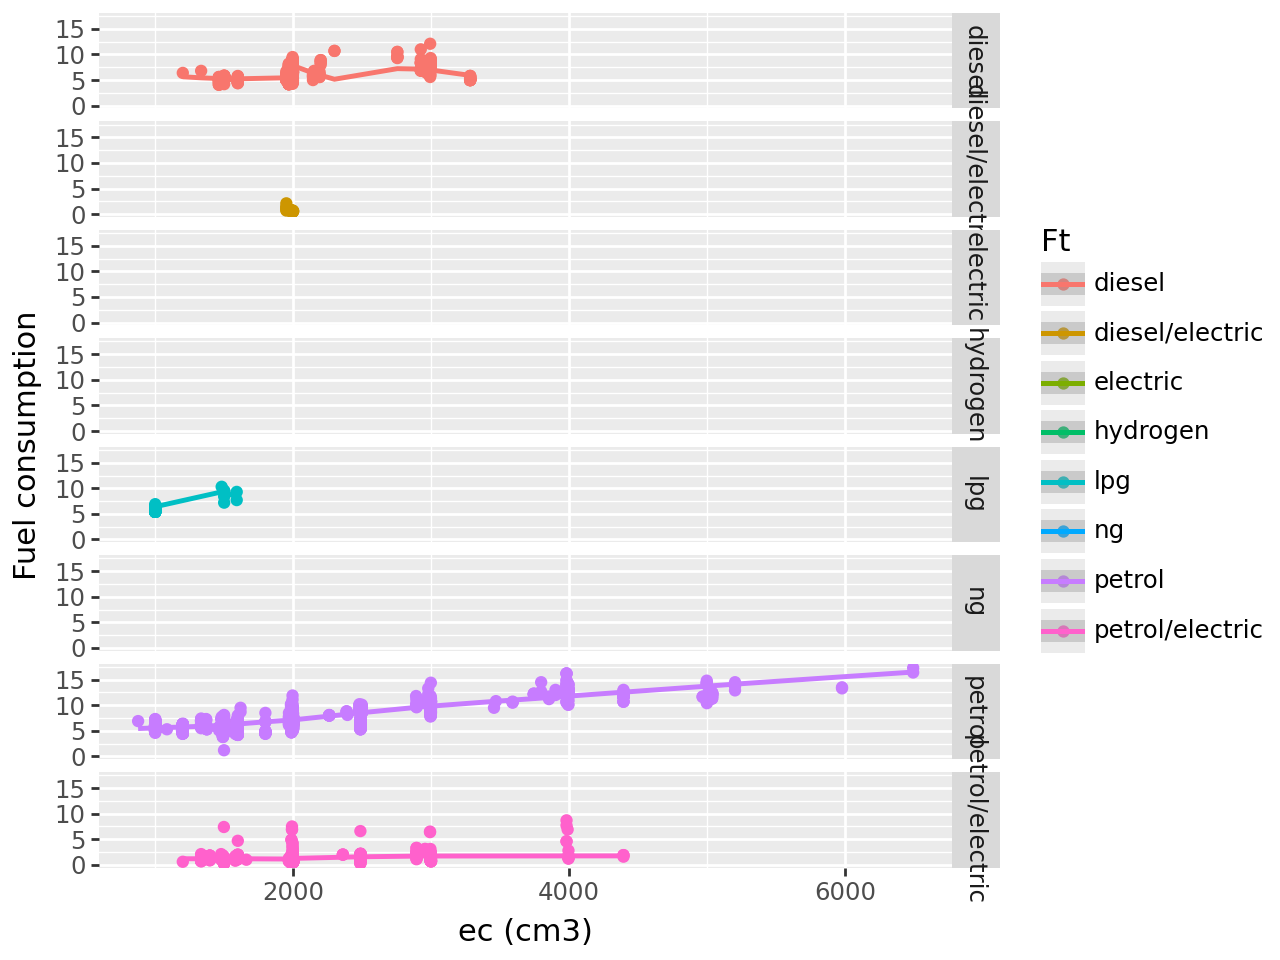

In [16]:
(
    ggplot(df)  # What data to use
    + aes(x = 'ec (cm3)', 
          y = 'Fuel consumption ',
         color = 'Ft')  # What variable to use
    + geom_point()
    + geom_smooth(method = 'lowess') 
    + facet_grid(rows = 'Ft')
)

/home/pedro/Escritorio/UCM_2026/entorno_junio/lib/python3.12/site-packages/plotnine/stats/smoothers.py:342: PlotnineWarning: Confidence intervals are not yet implemented for lowess smoothings.
/home/pedro/Escritorio/UCM_2026/entorno_junio/lib/python3.12/site-packages/statsmodels/nonparametric/smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
/home/pedro/Escritorio/UCM_2026/entorno_junio/lib/python3.12/site-packages/plotnine/layer.py:374: PlotnineWarning: geom_point : Removed 1622 rows containing missing values.


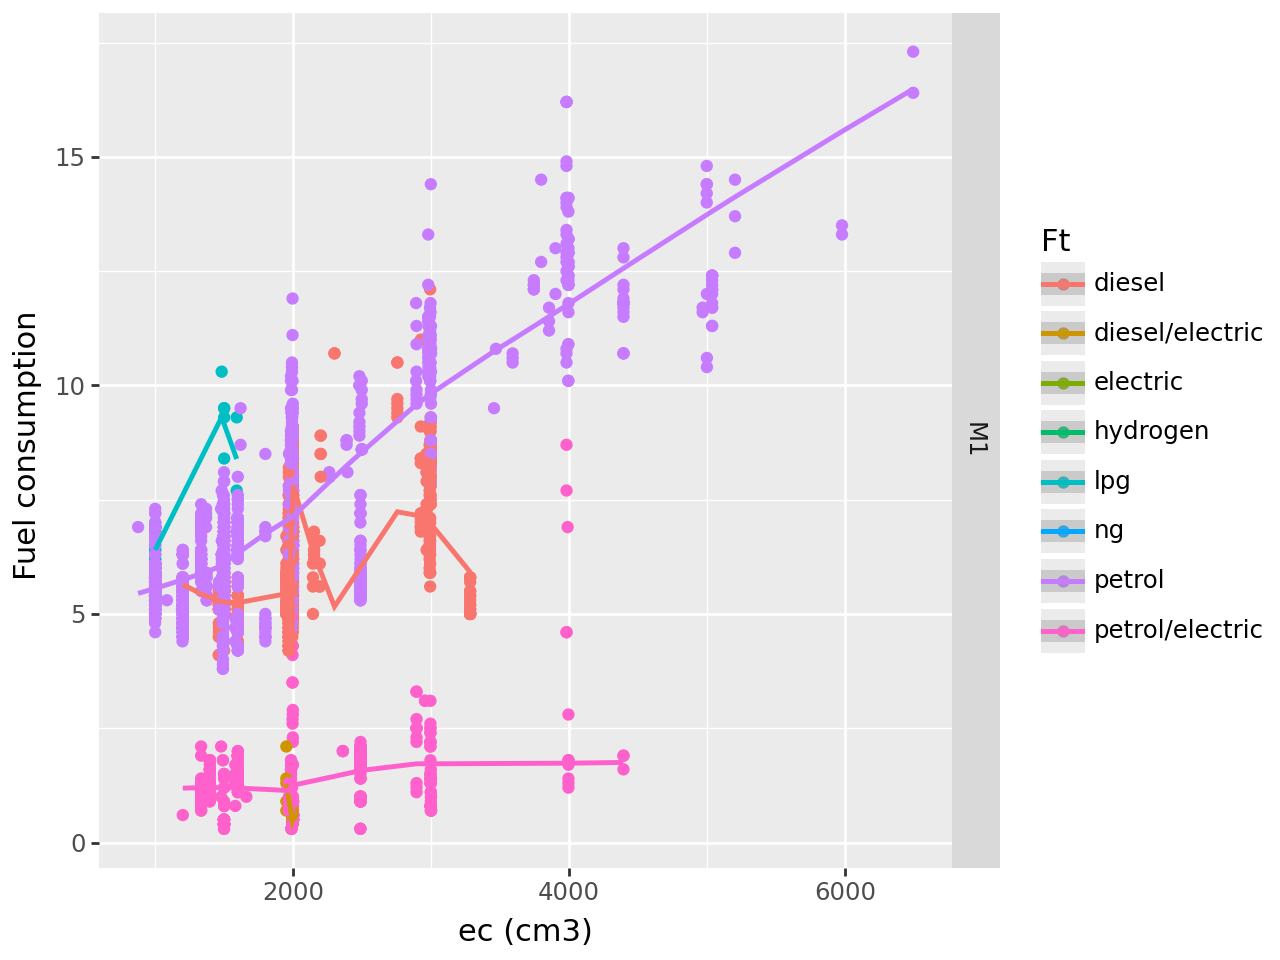

In [17]:
(
    ggplot(df)  # What data to use
    + aes(x = 'ec (cm3)', 
          y = 'Fuel consumption ',
         color = 'Ft')  # What variable to use
    + geom_point()
    + geom_smooth(method = 'lowess') 
    + facet_grid(rows = 'Ct')
)

In [18]:
g

NameError: name 'g' is not defined

In [ ]:
g = g + theme(figure_size=(12, 12))

In [ ]:
g.save("primer_scatterplot_2.png", dpi = 300)